# Import 

In [10]:
# Dycore Initial Analysis Notebook
# Author: Chin-Yu Chang
# Description: Analyze 6-hourly Dycore output (u, v, T, geopotential, etc.)
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Function: Read Dycore Data

In [11]:
def read_Dycore_data(filepath, print_var=False):
    """
    Load Dycore data from HDF5 file.
    
    Parameters:
        filepath (str): Path to the Dycore HDF5 file.
        print_var (bool): If True, print available variable names.
    
    Returns:
        tuple: u, v, t, p, ps, w, phi arrays
    """
    with h5py.File(filepath, "r") as f:
        if print_var:
            print("Available variables:", list(f.keys()))
        
        u   = f["grid_u_c_xyzt"][:]       # Zonal wind
        v   = f["grid_v_c_xyzt"][:]       # Meridional wind
        t   = f["grid_t_c_xyzt"][:]       # Temperature
        p   = f["grid_p_full_xyzt"][:]    # 3D pressure
        ps  = f["grid_ps_c_xyzt"][:]      # Surface pressure
        w   = f["grid_w_full_xyzt"][:]    # Vertical velocity
        phi = f["grid_geopots_xyzt"][:]   # Geopotential
        qv  = f["grid_tracers_c_xyzt"][:] # Specific humidity (tracers) 
        print(f.keys())                   # all variables' names
        
    return u, v, t, p, ps, w, phi, qv

In [12]:
# Read var
file_path = "Dycore_50day_all_day.dat"
u, v, t, p, ps, w, phi, qv = read_Dycore_data(file_path, print_var=False)

# Grid information
ny = u.shape[2] # 64
y = np.linspace(-90, 90, ny)

# Compute sigma (mean over time/zonal)
sigma = np.mean(p / ps, axis=(0, 2, 3))

<KeysViewHDF5 ['_types', 'convection_xyzt', 'factor1_xyzt', 'factor2_xyzt', 'factor3_xyzt', 'factor4_xyzt', 'grid_div_xyzt', 'grid_geopots_xyzt', 'grid_p_full_xyzt', 'grid_p_half_xyzt', 'grid_ps_c_xyzt', 'grid_ps_p_xyzt', 'grid_t_c_xyzt', 'grid_t_n_xyzt', 'grid_t_p_xyzt', 'grid_tracers_c_xyzt', 'grid_tracers_diff_xyzt', 'grid_tracers_n_xyzt', 'grid_tracers_p_xyzt', 'grid_u_c_xyzt', 'grid_u_n_xyzt', 'grid_u_p_xyzt', 'grid_v_c_xyzt', 'grid_v_n_xyzt', 'grid_v_p_xyzt', 'grid_vor_xyzt', 'grid_w_full_xyzt', 'grid_z_full_xyzt', 'grid_δtracers_xyzt', 'grid_δu_xyzt', 'grid_δv_xyzt', 'spe_div_c_xyzt', 'spe_div_p_xyzt', 'spe_lnps_c_xyzt', 'spe_lnps_p_xyzt', 'spe_t_c_xyzt', 'spe_t_p_xyzt', 'spe_tracers_c_xyzt', 'spe_tracers_p_xyzt', 'spe_vor_c_xyzt', 'spe_vor_p_xyzt']>


In [13]:
# Checking dimension: (time, z, y, x)
u.shape 

(200, 20, 64, 128)

# U profile plot 

Text(0.5, 1.0, 'U wind')

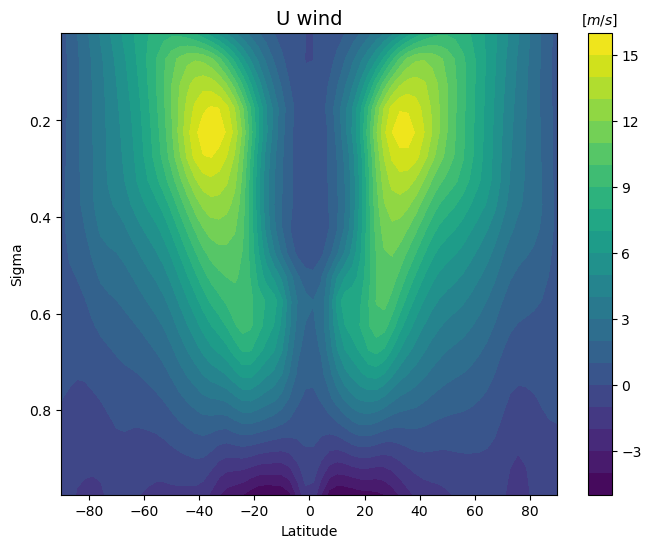

In [14]:
# u profile 
u_yz = np.mean(u, axis=(0,3)) # time/zonal mean

# plot
yy, sigmaa = np.meshgrid(y,sigma)

plt.figure(figsize=(8,6), dpi=100.)
CS = plt.contourf(yy, sigmaa, u_yz, levels=21)
CB = plt.colorbar(CS)
CB.ax.set_title("[$m/s$]", fontsize=10)
plt.gca().invert_yaxis()
plt.xlabel("Latitude")
plt.ylabel("Sigma")
plt.title("U wind", fontsize=14)


# T profile plot 

Text(0.5, 1.0, 'Temperature')

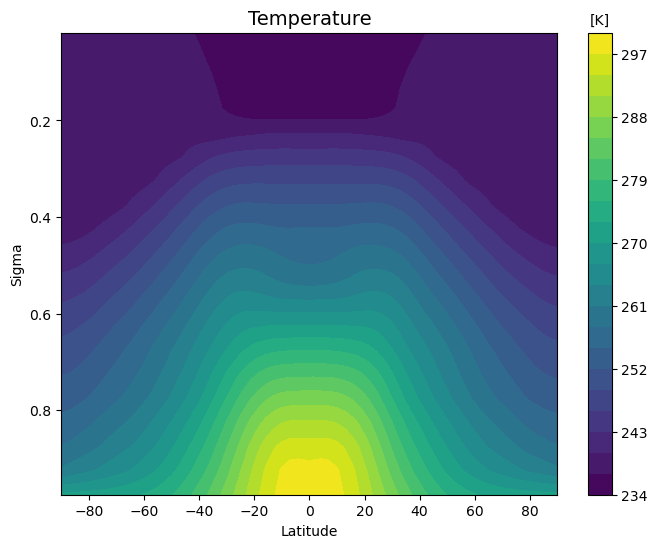

In [15]:
# t profile 
t_yz = np.mean(t, axis=(0,3)) # time/zonal mean

# plot
yy, sigmaa = np.meshgrid(y,sigma)

plt.figure(figsize=(8,6), dpi=100.)
CS = plt.contourf(yy, sigmaa, t_yz, levels=21)
CB = plt.colorbar(CS)
CB.ax.set_title("[K]", fontsize=10)
plt.gca().invert_yaxis()
plt.xlabel("Latitude")
plt.ylabel("Sigma")
plt.title("Temperature", fontsize=14)


# qv profile

Text(0.5, 1.0, 'Specific humidity')

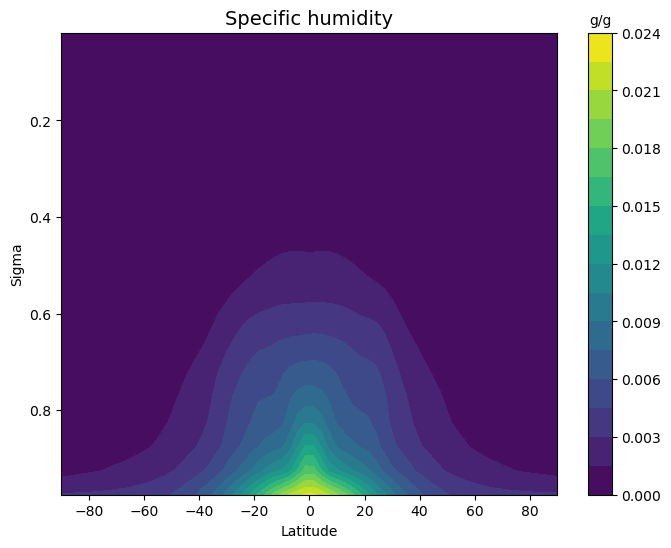

In [20]:
# qv profile 
qv_yz = np.mean(qv, axis=(0,3)) # time/zonal mean

# plot
yy, sigmaa = np.meshgrid(y,sigma)

plt.figure(figsize=(8,6), dpi=100.)
CS = plt.contourf(yy, sigmaa, qv_yz, levels=21)
CB = plt.colorbar(CS)
CB.ax.set_title("g/g", fontsize=10)
plt.gca().invert_yaxis()
plt.xlabel("Latitude")
plt.ylabel("Sigma")
plt.title("Specific humidity", fontsize=14)
